In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 12
})


In [24]:
import numpy as np

In [29]:
import pandas as pd
a_cn = pd.read_csv("normal_force_coeff_M0.85.csv", names=['alpha', 'cn'])
cn_cd = pd.read_csv("cn_cd_M0.85.csv", names=['c_n', 'cd'])

a_cn[0:24]

,alpha,cn
0,0.254600,0.026005
1,0.616205,0.070749
2,1.020224,0.119652
3,1.296882,0.155036
4,1.552211,0.187296
5,1.828748,0.221635
6,2.105527,0.258062
7,2.381941,0.291357
8,2.679441,0.325688
9,2.998512,0.365230


In [38]:
top = cn_cd['c_n'][0:23] - cn_cd['cd'][0:23] * np.sin(np.deg2rad(a_cn.alpha[0:23]))

cl = top / np.cos(np.deg2rad(a_cn.alpha[0:23]))

In [42]:
0.9*cl.max()*np.cos(np.deg2rad(35))

np.float64(0.5352219626292075)

In [41]:
cl.max()

np.float64(0.7259837459164113)

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
C:\Users\eneiche\AppData\Local\Temp\ipykernel_19476\2208280774.py:3: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("Angle of Attack ($^\circ$)")


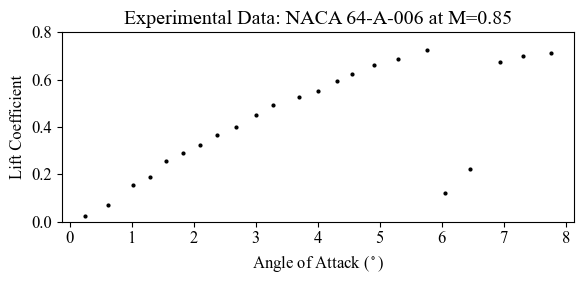

In [69]:
plt.figure(figsize=[6, 3])
plt.scatter(a_cn.alpha[0:23], cl, s=4, color='k')
plt.xlabel("Angle of Attack ($^\circ$)")
plt.ylabel("Lift Coefficient")
plt.ylim([0, 0.8])
plt.title("Experimental Data: NACA 64-A-006 at M=0.85")
plt.tight_layout()
plt.savefig("transonic_cl.pdf")


In [10]:
cn_cd = cn_cd.sort_values('c_n')

cn_cd

,c_n,cd
0,0.025983,0.004868
1,0.070919,0.004961
18,0.119669,0.004969
2,0.155283,0.005316
3,0.187081,0.005576
19,0.222274,0.006092
4,0.258316,0.006694
5,0.291393,0.007380
6,0.325323,0.008406
7,0.365196,0.009943


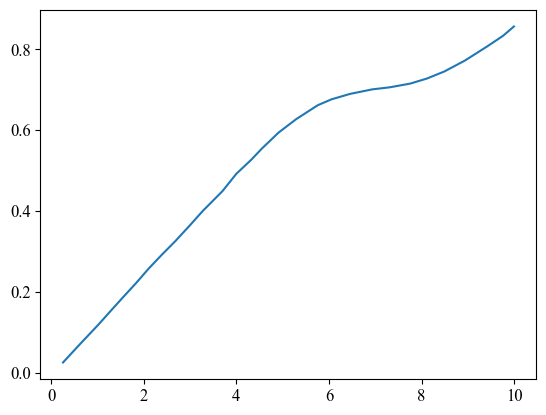

In [ ]:
plt.plot(a_cn['alpha'], a_cn['cn'])


In [44]:
from ambiance import Atmosphere

a = lambda h: Atmosphere(h*0.3048).speed_of_sound * 3.2808399 # converts m/s to ft/s
rho = lambda h: Atmosphere(h*0.3047).density * 0.00194

kinematic_viscosity = lambda h: Atmosphere(h*0.3048).kinematic_viscosity * 3.2808399**2 # convert from m^2/s to ft^2/s

In [46]:
Ma = 0.2
V = Ma * a(0)
V * 12.79579 / kinematic_viscosity(0)

array([18171876.93002834])

In [71]:
w

,alpha,CL,CD,CDp,CM,Top_Xtr,Bot_Xtr
0,0.3,0.0325,0.00478,0.00026,-0.0000,0.1440,0.2815
1,0.6,0.0645,0.00463,0.00027,-0.0000,0.0845,0.4054
2,0.9,0.0970,0.00456,0.00029,-0.0001,0.0531,0.4804
3,1.2,0.1299,0.00458,0.00033,-0.0001,0.0268,0.5220
4,1.5,0.1629,0.00459,0.00038,-0.0002,0.0143,0.5569
5,2.4,0.2621,0.00458,0.00057,-0.0003,0.0078,0.6607
6,2.7,0.2949,0.00461,0.00065,-0.0003,0.0045,0.6966
7,3.0,0.3278,0.00466,0.00077,-0.0003,0.0026,0.7294
8,3.3,0.3606,0.00472,0.00089,-0.0003,0.0019,0.7606
9,3.6,0.3932,0.00482,0.00104,-0.0002,0.0013,0.7840


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\eneiche\AppData\Local\Temp\ipykernel_19476\920369918.py:1: SyntaxWarning: invalid escape sequence '\s'
  w=pd.read_csv(r"R:\Programs\XFOIL\400pts.dat", skiprows=[1, 2, 3, 4, 5, 6, 7, 8, 9, 11], skipinitialspace=True, delimiter="\s+")
C:\Users\eneiche\AppData\Local\Temp\ipykernel_19476\920369918.py:5: SyntaxWarning: invalid escape sequence '\c'
  plt.xlabel("Angle of Attack ($^\circ$)")


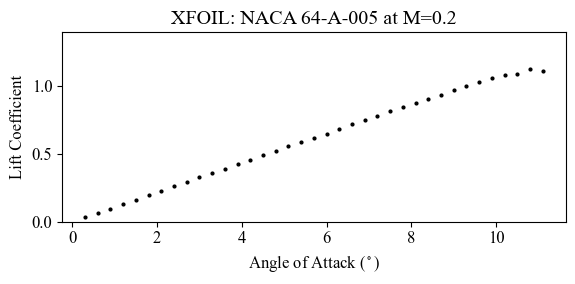

In [74]:
w=pd.read_csv(r"R:\Programs\XFOIL\400pts.dat", skiprows=[1, 2, 3, 4, 5, 6, 7, 8, 9, 11], skipinitialspace=True, delimiter="\s+")

plt.figure(figsize=[6, 3])
plt.scatter(w.alpha, w.CL, color='k', s=4)
plt.xlabel("Angle of Attack ($^\circ$)")
plt.ylabel("Lift Coefficient")
plt.ylim([0, 1.4])
plt.title("XFOIL: NACA 64-A-005 at M=0.2")
plt.tight_layout()
plt.savefig("subsonicsonic_cl.pdf")